# Elaborato di Apprendimento Automatico e Apprendimento Profondo

## Classificazione della sopravvivenza a follow-up in pazienti con scompenso cardiaco

**Nicola Piero Palo — Matricola 0322500145**

Dataset: *Heart Failure Clinical Records* (UCI Machine Learning Repository, id 519)


## 0. Setup, caricamento del dataset e preprocessing


In [1]:
# ==============================================================
# 0. SETUP E CARICAMENTO DEL DATASET
# ==============================================================

!pip install ucimlrepo shap -q   # solo su Colab; in locale bisogna togliere il "!"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Dataset: Heart Failure Clinical Records (id UCI = 519)
# 299 pazienti, 12 feature cliniche, target binario
heart = fetch_ucirepo(id=519)

X = heart.data.features.copy()                  # feature (DataFrame)
y = heart.data.targets.iloc[:, 0].astype(int)   # target: 1 = deceduto, 0 = sopravvissuto

# --- prima esplorazione ---
print(heart.variables)              # tabella con tipo e descrizione di ogni variabile
print(X.describe().T.round(2))      # statistiche descrittive
print(y.value_counts())             # bilanciamento delle classi
print("Valori mancanti totali:", X.isnull().sum().sum())

# --- SCELTA PROGETTUALE: la feature "time" ---
# "time" = giorni di follow-up del paziente. Chi muore presto ha un follow-up breve:
# quindi la feature "svela" in parte l'esito -> leakage informativo.
# Decido di escluderla, la scelta la motiverò all'interno della relazione.
X = X.drop(columns=['time'])

# ==============================================================
# 0b. SUDDIVISIONE TRAIN / VALIDATION / TEST E STANDARDIZZAZIONE
# ==============================================================

# 70% train, 15% validation, 15% test.
# stratify=y mantiene le proporzioni delle classi in ogni split.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Standardizzazione: fit SOLO sul training set per evitare data leakage.
# Lo scaler "impara" media e deviazione standard dal train...
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
# ...e sugli altri set si limita ad APPLICARE i parametri già calcolati
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "| Validation:", X_val.shape, "| Test:", X_test.shape)

                        name     role        type demographic  \
0                        age  Feature     Integer         Age   
1                    anaemia  Feature      Binary        None   
2   creatinine_phosphokinase  Feature     Integer        None   
3                   diabetes  Feature      Binary        None   
4          ejection_fraction  Feature     Integer        None   
5        high_blood_pressure  Feature      Binary        None   
6                  platelets  Feature  Continuous        None   
7           serum_creatinine  Feature  Continuous        None   
8               serum_sodium  Feature     Integer        None   
9                        sex  Feature      Binary         Sex   
10                   smoking  Feature      Binary        None   
11                      time  Feature     Integer        None   
12               death_event   Target      Binary        None   

                                          description             units  \
0             

## 1. Analisi delle feature mediante PCA


Componenti per l'80% della varianza: 8
PC1: 15.2%  (cumulata: 15.2%)
PC2: 12.8%  (cumulata: 28.0%)
PC3: 11.1%  (cumulata: 39.1%)
PC4: 10.1%  (cumulata: 49.1%)
PC5: 9.5%  (cumulata: 58.6%)
PC6: 9.0%  (cumulata: 67.7%)
PC7: 7.8%  (cumulata: 75.4%)
PC8: 7.4%  (cumulata: 82.8%)
PC9: 6.6%  (cumulata: 89.4%)
PC10: 5.9%  (cumulata: 95.3%)
PC11: 4.7%  (cumulata: 100.0%)


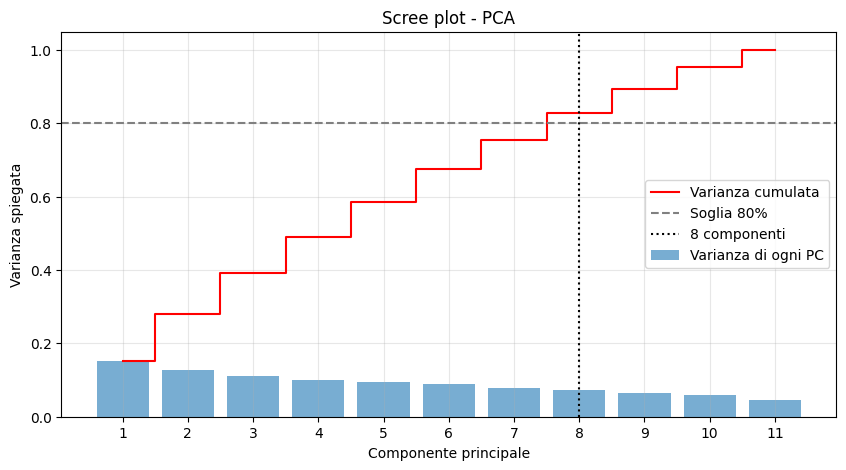

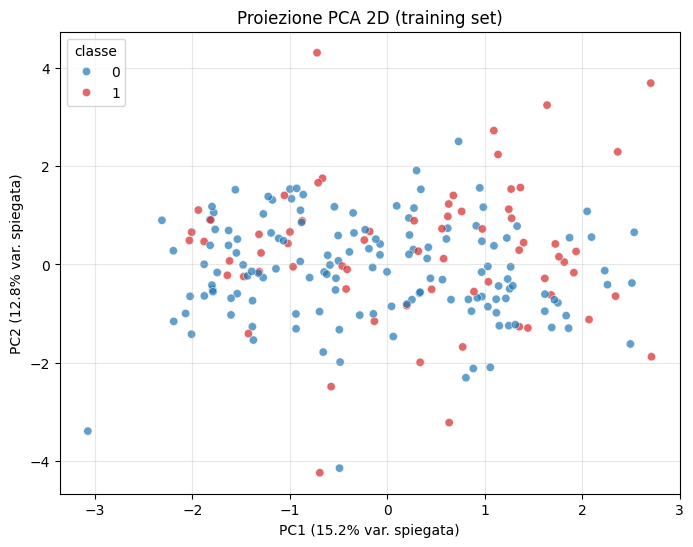

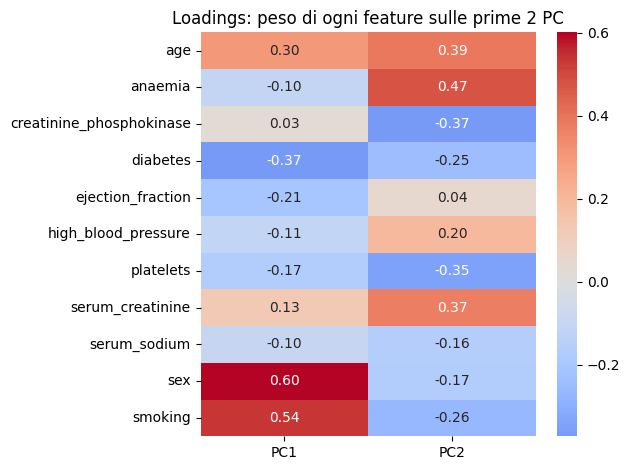

In [2]:
# ==============================================================
# 1. ANALISI DELLE FEATURE MEDIANTE PCA
# ==============================================================

# 1a. PCA completa: quante componenti servono?
pca_full = PCA().fit(X_train_s)          # senza n_components tiene tutte le PC

var_exp = pca_full.explained_variance_ratio_   # varianza spiegata da ogni PC
var_cum = np.cumsum(var_exp)                   # varianza cumulata

n80 = np.argmax(var_cum >= 0.80) + 1           # PC necessarie per l'80% di varianza
print(f"Componenti per l'80% della varianza: {n80}")
for i, (v, c) in enumerate(zip(var_exp, var_cum), start=1):
    print(f"PC{i}: {v:.1%}  (cumulata: {c:.1%})")

# --- Scree plot ---
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, label='Varianza di ogni PC')
plt.step(range(1, len(var_cum)+1), var_cum, where='mid',
         color='red', label='Varianza cumulata')
plt.axhline(0.80, color='gray', ls='--', label='Soglia 80%')
plt.axvline(n80, color='black', ls=':', label=f'{n80} componenti')
plt.xlabel('Componente principale'); plt.ylabel('Varianza spiegata')
plt.title('Scree plot - PCA'); plt.legend(); plt.grid(alpha=0.3)
plt.xticks(range(1, len(var_exp)+1))
plt.show()

# 1b. Proiezione 2D: separabilità visiva delle classi
pca_2d = PCA(n_components=2).fit(X_train_s)   # fittata SOLO sul train, come lo scaler
X2d = pca_2d.transform(X_train_s)

df2d = pd.DataFrame(X2d, columns=['PC1', 'PC2'])
df2d['classe'] = y_train.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df2d, x='PC1', y='PC2', hue='classe',
                palette={0: 'tab:blue', 1: 'tab:red'}, alpha=0.7)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var. spiegata)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var. spiegata)")
plt.title('Proiezione PCA 2D (training set)')
plt.grid(alpha=0.3)
plt.show()

# 1c. (opzionale ma consigliato) Contributo delle feature originali a PC1 e PC2
loadings = pd.DataFrame(pca_2d.components_.T,
                        index=X.columns, columns=['PC1', 'PC2'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Loadings: peso di ogni feature sulle prime 2 PC')
plt.tight_layout()
plt.show()

## 2. Algoritmi di classificazione


In [3]:
# ==============================================================
# 2. ALGORITMI DI CLASSIFICAZIONE
# ==============================================================
# Scelgo tre algoritmi con approcci molto diversi tra loro:
# - Logistic Regression: modello LINEARE (confine decisionale lineare)
# - SVM con kernel RBF:  modello a KERNEL (confine non lineare, flessibile)
# - Random Forest:       ensemble di ALBERI (cattura interazioni tra feature)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

# --- 2a. Stabilità dei modelli: cross-validation a 5 fold sul TRAIN ---
# La CV stima quanto le performance dipendono dalla particolare
# suddivisione dei dati. Serve a una valutazione di robustezza,
# NON alla scelta degli iperparametri (che avviene sul validation).
modelli = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42),
}

print("--- Cross-validation sul training set (ROC-AUC, 5 fold) ---")
for nome, m in modelli.items():
    cv_auc = cross_val_score(m, X_train_s, y_train, cv=5, scoring="roc_auc")
    print(f"{nome}: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")

# --- 2b. Scelta degli iperparametri sul VALIDATION set ---
# Regola: il test set si usa UNA SOLA VOLTA, alla fine (punto 3).

# Logistic Regression: forza della regolarizzazione L2
risultati = []
for c in [0.01, 0.1, 1, 10]:
    m = LogisticRegression(C=c, max_iter=1000, random_state=42).fit(X_train_s, y_train)
    auc = roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])
    risultati.append((auc, c))
best_c = max(risultati, key=lambda r: r[0])[1]
print(f"\nLR - miglior C sul validation: {best_c}")

# SVM: C (margine) e gamma (ampiezza d'influenza dei singoli punti)
risultati = []
for c in [0.1, 1, 10]:
    for g in ["scale", 0.01, 0.1]:
        m = SVC(kernel="rbf", C=c, gamma=g, probability=True,
                random_state=42).fit(X_train_s, y_train)
        auc = roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])
        risultati.append((auc, c, g))
best_svm = max(risultati, key=lambda r: r[0])
print(f"SVM - migliori iperparametri: C={best_svm[1]}, gamma={best_svm[2]}")

# Random Forest: numero di alberi e profondità massima
risultati = []
for n in [100, 300]:
    for d in [None, 4, 8]:
        m = RandomForestClassifier(n_estimators=n, max_depth=d,
                                   random_state=42).fit(X_train_s, y_train)
        auc = roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])
        risultati.append((auc, n, d))
best_rf = max(risultati, key=lambda r: r[0])
print(f"RF - migliori iperparametri: n_estimators={best_rf[1]}, max_depth={best_rf[2]}")

# --- 2c. Modelli finali ---
# Dopo aver scelto gli iperparametri sul validation, ri-addestro su
# train+validation per non sprecare quei dati. Il test resta intatto.
X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval = pd.concat([y_train, y_val])

modelli_finali = {
    "Logistic Regression": LogisticRegression(C=best_c, max_iter=1000, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", C=best_svm[1], gamma=best_svm[2],
                               probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=best_rf[1],
                                                  max_depth=best_rf[2],
                                                  random_state=42),
}
for nome, m in modelli_finali.items():
    m.fit(X_trainval_s, y_trainval)
print("\nModelli finali addestrati su train+validation.")

--- Cross-validation sul training set (ROC-AUC, 5 fold) ---
Logistic Regression: 0.791 ± 0.070
SVM (RBF): 0.757 ± 0.099
Random Forest: 0.783 ± 0.090

LR - miglior C sul validation: 0.01
SVM - migliori iperparametri: C=10, gamma=0.01
RF - migliori iperparametri: n_estimators=100, max_depth=4

Modelli finali addestrati su train+validation.


## 3. Metriche di valutazione sul test set


In [4]:
# ==============================================================
# 3. METRICHE DI VALUTAZIONE SUL TEST SET
# ==============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

predizioni = {}    # classi predette -> per le matrici di confusione
probabilita = {}   # probabilità classe 1 -> per le curve ROC
righe = {}

for nome, m in modelli_finali.items():
    y_pred = m.predict(X_test_s)
    y_prob = m.predict_proba(X_test_s)[:, 1]   # probabilità della classe positiva

    predizioni[nome] = y_pred
    probabilita[nome] = y_prob

    righe[nome] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC AUC":   roc_auc_score(y_test, y_prob),
    }

df_metriche = pd.DataFrame(righe).T.round(3)
print("--- Metriche sul test set ---")
print(df_metriche)

--- Metriche sul test set ---
                     Accuracy  Precision  Recall     F1  ROC AUC
Logistic Regression     0.667      0.333   0.071  0.118    0.677
SVM (RBF)               0.644      0.429   0.429  0.429    0.668
Random Forest           0.689      0.500   0.286  0.364    0.719


## 4. Matrici di confusione e curve ROC


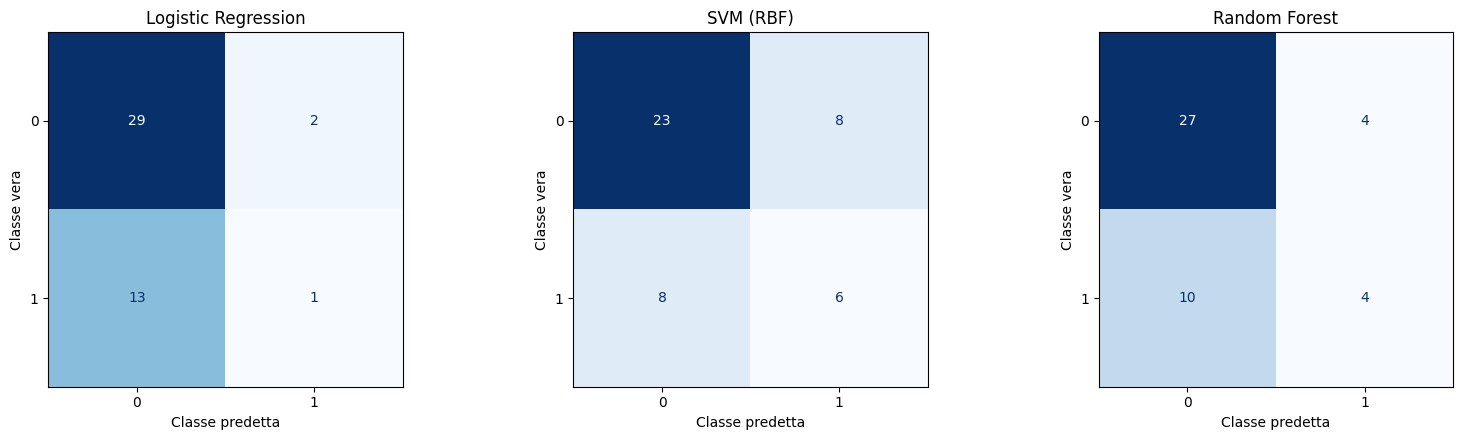

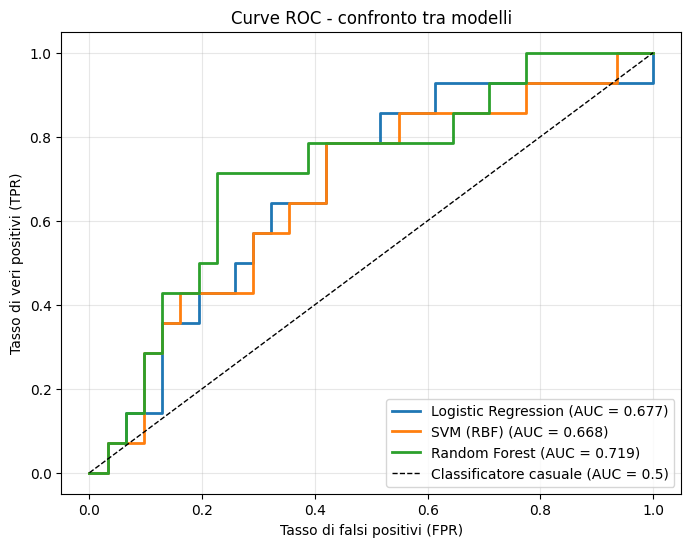

In [5]:
# ==============================================================
# 4. MATRICI DI CONFUSIONE E CURVE ROC
# ==============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# --- 4a. Matrici di confusione (una per modello) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, _) in zip(axes, modelli_finali.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predizioni[nome], ax=ax, cmap="Blues",
        colorbar=False, values_format="d")
    ax.set_title(nome)
    ax.set_xlabel("Classe predetta")
    ax.set_ylabel("Classe vera")
plt.tight_layout()
plt.show()

# --- 4b. Curve ROC sovrapposte ---
plt.figure(figsize=(8, 6))
for nome, y_prob in probabilita.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2,
             label=f"{nome} (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Classificatore casuale (AUC = 0.5)")
plt.xlabel("Tasso di falsi positivi (FPR)")
plt.ylabel("Tasso di veri positivi (TPR)")
plt.title("Curve ROC - confronto tra modelli")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 5b. Spiegabilità del modello: SHAP (TreeExplainer)


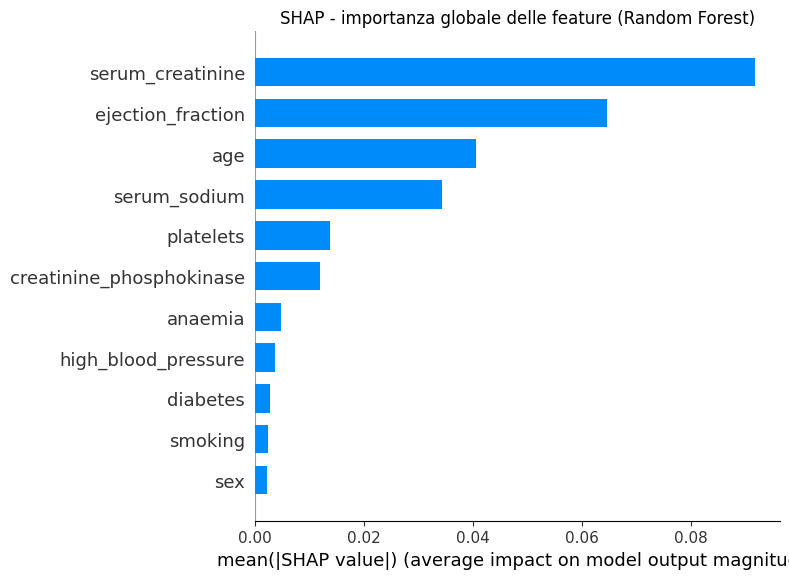

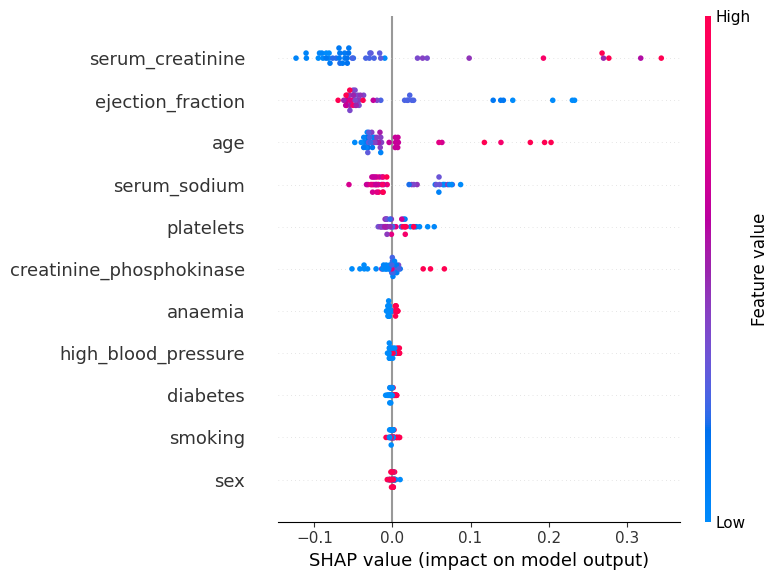

In [6]:
# ==============================================================
# 5b. SPIEGABILITÀ: SHAP (TreeExplainer) SULLA RANDOM FOREST
# ==============================================================
import shap

rf = modelli_finali["Random Forest"]

# TreeExplainer calcola i valori di Shapley in modo ESATTO e rapido
# per i modelli ad albero (con KernelExplainer richiederebbero
# tempi molto maggiori e sarebbero solo approssimati).
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_s)

# Gestione dei due formati possibili a seconda della versione di shap:
# - lista [classe_0, classe_1]
# - array 3D (campioni, feature, classi)
if isinstance(shap_values, list):
    sv_pos = shap_values[1]            # contributi per la classe 1 (decesso)
else:
    sv_pos = shap_values[:, :, 1]

# I dati scalati vanno rimessi in un DataFrame per avere i nomi delle feature
X_test_df = pd.DataFrame(X_test_s, columns=X.columns)

# 5b.1 - Importanza globale: media dei valori SHAP assoluti
shap.summary_plot(sv_pos, X_test_df, plot_type="bar", show=False)
plt.title("SHAP - importanza globale delle feature (Random Forest)")
plt.tight_layout()
plt.show()

# 5b.2 - Beeswarm: direzione dell'effetto
# Colore rosso = valore alto della feature, blu = valore basso;
# asse x = impatto sulla probabilità della classe 1 (decesso).
shap.summary_plot(sv_pos, X_test_df, show=False)
plt.tight_layout()
plt.show()